# Monte Carlo Project 3

**Ricky Li, Margie Bold**

### Tasks and corrsponding conditional distributions of Interest:

Under fixed $\theta$:

1. Filtering:         $X_t | Y_{[0:t]}$
2. Prediction:        $X_t | Y_{[0:t-1]}$
3. Data Prediction:   $Y_t | Y_{[0:t-1]}$
4. Fixed-lag smoothing: $X_{[t-h:t]} | Y_{[0:t]}$
5. Complete smoothing: $X_{[0:t]} | Y_{[0:t]}$
6. Likelihood factor: density of $Y_t | Y_{[0:t-1]}$

Without fixed $\theta$:

7. Parameter Estimation (Bayesian approach and filtering): law of $(\theta,X_t)$ given $Y_{[0:t]}$


### Imports and Setup

In [18]:
!pip install -q filterpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from filterpy.kalman import KalmanFilter
import scipy.stats as stats

# from scipy.stats import invgamma

In [20]:
from particle_filter import particle_filter, particle_filter_student_t, _systematic_resample
from state_space_model import (
    log_likelihood, pf_log_likelihood, neg_log_lik,
    kalman_negloglike_alpha_fixed, log_prior, pmmh,
)
from regime_switching import (
    bootstrap_pf_regime_switching, pmmh_regime_switching,
    constrain_theta, unconstrain_theta,
    log_prior_z, pf_log_likelihood_regime,
)
from analysis_utils import compare_arima_models

### State-space model

*State equation:*  $\;x_t = \phi x_{t-1} + \epsilon_t,\quad \epsilon_t \sim N(0,\sigma^2)$

*Measurement equation:*  $\;y_t = \alpha x_t + \nu_t,\quad \nu_t \sim N(0,\tau^2)$

Let $\theta = (\phi,\alpha,\sigma,\tau)$.


### Analysis of the model

**A. Non-identifiability of $\alpha$ and $\sigma$.**
Let $z_t = \alpha x_t$. The state-space model can be rewritten as
$$z_t = \phi z_{t-1} + \tilde{\epsilon}_t,\ \tilde{\epsilon}_t \sim N(0,\alpha^2 \sigma^2);\qquad y_t = z_t + \nu_t,\ \nu_t \sim N(0,\tau^2).$$

Therefore an assumption on $\alpha$, $\sigma$, or the magnitude of $x_t$ is needed to estimate the parameters or the Bayesian posteriro $p(x_{[0:t]}, \phi, \sigma, \alpha, \tau \mid y_{[0:t]})$.

**B. Stationary latent process.**
The latent state is AR(1) (under $|\phi| < 1$), so taking $x_0 \sim N\!\left(0,\tfrac{\sigma^2}{1-\phi^2}\right)$ gives
$$m_x = 0,\qquad \mathrm{Cov}(x_s, x_t) = \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|}.$$

**C. ARMA(1,1) representation of $y_t$.**
Rearranging the equations,
$$y_t = \phi y_{t-1} + \tilde{\epsilon}_t + \nu_t - \phi \nu_{t-1}.$$

Under the same initial distribution for $x_0$,
$$
y \sim N(0, \Sigma_y),
\quad
(\Sigma_y)_{st} = \alpha^2 \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|} + \tau^2 \boldsymbol{1}_{s=t}.
$$

**D. Likelihood ratio.**

Let

$$
\Sigma_\theta := \Sigma_y,
\qquad
\Sigma_{\theta'} := \Sigma_y'.
$$

Then

$$
\Lambda(\theta' \mid \theta)
=
\frac{p_{\theta'}(y_{0:T})}{p_{\theta}(y_{0:T})}
=
\sqrt{
\frac{|\Sigma_\theta|}{|\Sigma_{\theta'}|}
}
\exp\left(
\frac{1}{2}
y^\top
\left[
\Sigma_\theta^{-1}
-
\Sigma_{\theta'}^{-1}
\right]
y
\right).
$$


### MLE preliminaries

**Conditional independence.** The latent state is Markov and the observation depends only on the current state:
$$p(x_t\mid x_{0:t-1},y_{0:t-1},\theta) = p(x_t\mid x_{t-1},\theta),\qquad p(y_t\mid x_{0:t},y_{0:t-1},\theta) = p(y_t\mid x_t,\theta).$$

Hence the joint density factors as
$$p(x_{0:T},y_{0:T}\mid \theta) = p(x_0) \prod_{t=1}^T \varphi(x_t;\phi x_{t-1},\sigma^2) \prod_{t=0}^T \varphi(y_t;\alpha x_t,\tau^2).$$

**Observed-data likelihood.** Integrating out the latent path,
$$L(\theta) = p(y_{0:T}\mid \theta) = \int p(x_0) \prod_{t=1}^T \varphi(x_t;\phi x_{t-1},\sigma^2) \prod_{t=0}^T \varphi(y_t;\alpha x_t,\tau^2)\, dx_{0:T},$$
and the MLE is $\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \log L(\theta).$


# Part I. Synthetic Data Generation

reading links (wip by Margie):

https://intro.quantecon.org/ar1_processes.html

https://python.quantecon.org/ar1_turningpts.html


In [21]:
np.random.seed(9)

# true params
phi_true = 0.9
alpha_true = 1.5
sigma_true = 0.5
tau_true = 1.0

T = 200
x0 = 0.0  # PROF Hirsa! x0 ~ N(0, sigma²/(1-phi²)) instead?

# latent x_t
x_true = np.zeros(T)
x_true[0] = phi_true * x0 + np.random.normal(0, sigma_true)
for t in range(1, T):
    x_true[t] = phi_true * x_true[t - 1] + np.random.normal(0, sigma_true)

# obs y_t
y_obs = alpha_true * x_true + np.random.normal(0, tau_true, size=T)

# t
t = np.arange(T)

In [22]:
# if you want lol, otherwise will delete later cuz i don't think df is needed.
data = pd.DataFrame({
    "t": np.arange(T),
    "x_true": x_true,
    "y_obs": y_obs
})

In [23]:
print("=" * 60)
print("synthetic data")
print("-" * 60)
print(f"T = {T} time steps | x_true: {x_true.shape} | y_obs: {y_obs.shape}\n")

print(f"{'t':>5}  {'x_true':>10}  {'y_obs':>10}")
print("-" * 30)
for i in range(5):
    print(f"{t[i]:>5}  {x_true[i]:>10.4f}  {y_obs[i]:>10.4f}")
print("  ...")
for i in range(-5, 0):
    print(f"{t[i]:>5}  {x_true[i]:>10.4f}  {y_obs[i]:>10.4f}")

print("=" * 60)

synthetic data
------------------------------------------------------------
T = 200 time steps | x_true: (200,) | y_obs: (200,)

    t      x_true       y_obs
------------------------------
    0      0.0006     -1.1841
    1     -0.1443     -1.2472
    2     -0.6879     -1.9467
    3     -0.6255     -1.7625
    4     -0.7522     -1.8656
  ...
  195     -0.2472     -2.6336
  196     -0.2830      0.9184
  197     -0.7711     -1.4702
  198     -0.2763      0.0235
  199     -0.6747     -1.6131


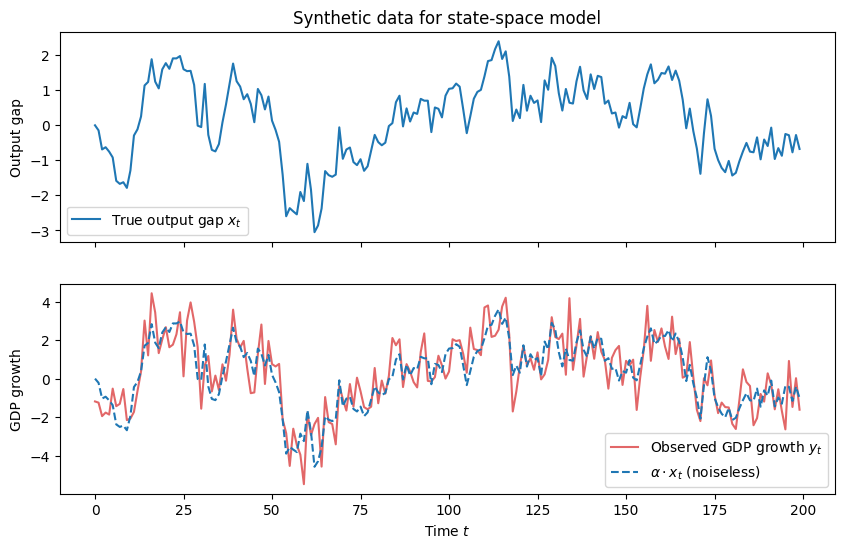

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, x_true, label="True output gap $x_t$", color="tab:blue")
axes[0].set_ylabel("Output gap")
axes[0].legend()
axes[0].set_title("Synthetic data for state-space model")

axes[1].plot(t, y_obs, label="Observed GDP growth $y_t$", color="tab:red", alpha=0.7)
axes[1].plot(t, alpha_true * x_true, label=r"$\alpha \cdot x_t$ (noiseless)", color="tab:blue", linestyle="--")
axes[1].set_ylabel("GDP growth")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

In [25]:
arima_model = compare_arima_models(y_obs, p_values=range(0, 5),
    d_values=(0,),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="c")

arima_model[0:5]

,order,p,d,q,aic,bic,hqic,loglik,ljungbox_p,converged
0,"(1, 0, 1)",1,0,1,679.655290,692.808358,684.979214,-335.827645,0.400351,True
1,"(1, 0, 2)",1,0,2,678.392851,694.808870,685.038178,-334.196425,0.471739,True
2,"(4, 0, 0)",4,0,0,677.550721,697.219409,685.513548,-332.775360,0.589466,True
3,"(1, 0, 3)",1,0,3,677.907243,697.575931,685.870071,-332.953622,0.470158,True
4,"(2, 0, 1)",2,0,1,681.213640,697.654975,687.868546,-335.606820,0.494894,True


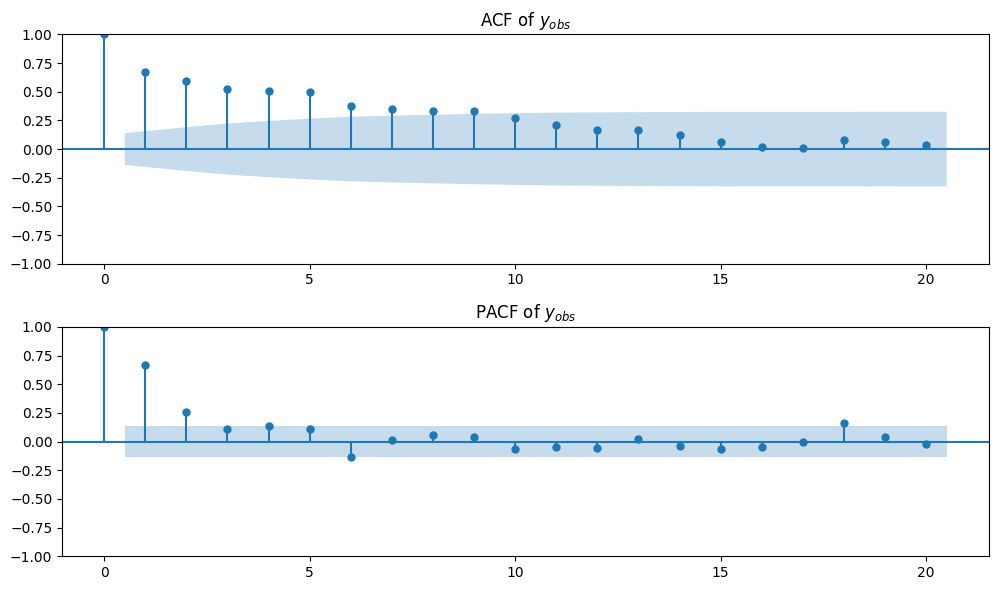

In [26]:
# plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(y_obs, lags=20, ax=axes[0])
plot_pacf(y_obs, lags=20, ax=axes[1])
axes[0].set_title("ACF of $y_{obs}$")
axes[1].set_title("PACF of $y_{obs}$")
plt.tight_layout()
plt.show()

# Part II. Filtering and Smoothing Problem using the true parameters

### 1. Particle Filter

reading links:

https://arxiv.org/abs/2511.01281

https://pmc.ncbi.nlm.nih.gov/articles/PMC7826670/

https://github.com/jelfring/particle-filter-tutorial

In [27]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [28]:
# Run particle filter with true parameters
N = 10000  # number of particles

np.random.seed(0)
x_pf_true, x_particles_true, weights_pf_true = particle_filter(
    y_obs, phi_true, alpha_true, sigma_true, tau_true, N_particles=N
)

rmse_pf_true = np.sqrt(np.mean((x_pf_true - x_true) ** 2))
print(f"Particle Filter (true params) RMSE: {rmse_pf_true:.4f}")

# alias kept for any cells downstream that referenced `history`
history = x_particles_true
final_estimate = x_pf_true[-1]
print(f"Final estimate for x_T is: {final_estimate}")

Particle Filter (true params) RMSE: 0.5161
Final estimate for x_T is: -0.738173266398652


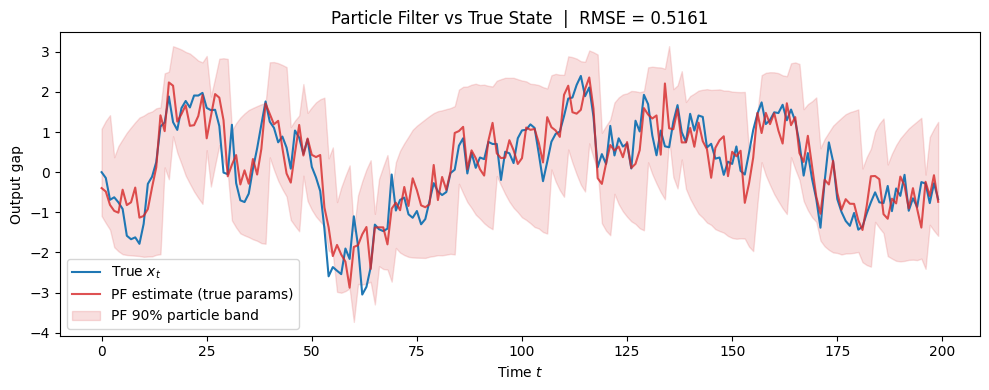

In [29]:
# PF est. vs truth
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_true, label="True $x_t$", color="tab:blue")
ax.plot(t, x_pf_true, label="PF estimate (true params)", color="tab:red", alpha=0.8)
ax.fill_between(
    t,
    np.percentile(x_particles_true, 5, axis=1),
    np.percentile(x_particles_true, 95, axis=1),
    color="tab:red", alpha=0.15, label="PF 90% particle band")

ax.set_xlabel("Time $t$")
ax.set_ylabel("Output gap")
ax.set_title(f"Particle Filter vs True State  |  RMSE = {rmse_pf_true:.4f}")
ax.legend()
plt.tight_layout()

Mean Squared Error: 0.26635614729073104
Root Mean Squared Error: 0.5160970328249631


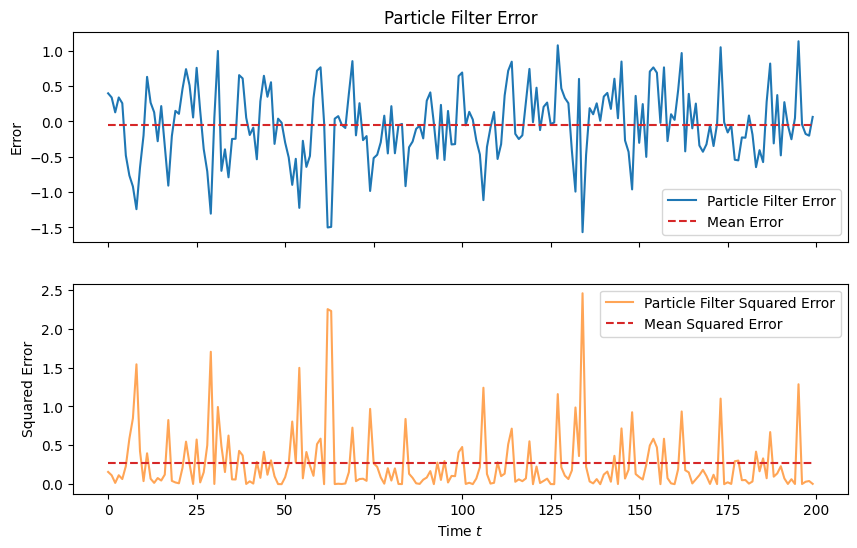

In [30]:
error = x_true - x_pf_true
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_particle = np.square(error).mean()
RMSE_particle = np.sqrt(MSE_particle)
SE_sigma_particle = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_particle}")
print(f"Root Mean Squared Error: {RMSE_particle}")

axes[0].plot(error, label="Particle Filter Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("Particle Filter Error")

axes[1].plot(error**2, label="Particle Filter Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_particle * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

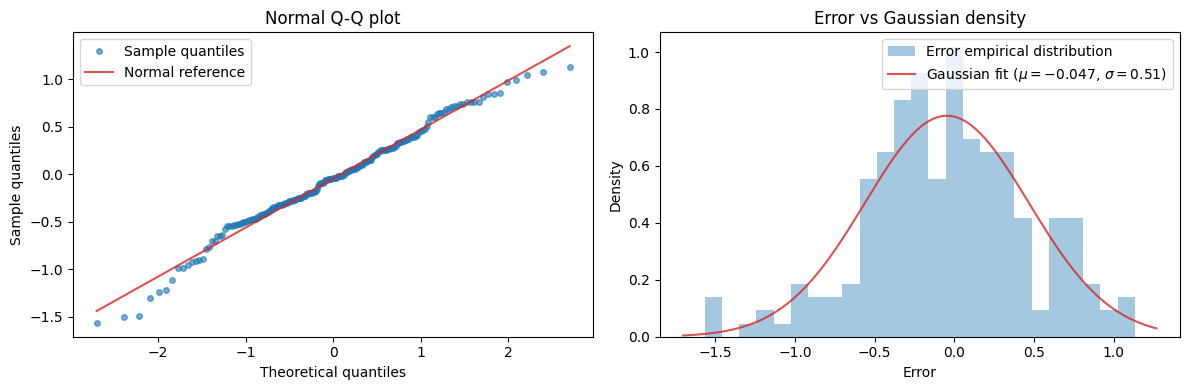

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Normal Q-Q plot — built manually so we can match the rest of the notebook's style
(osm, osr), (slope, intercept, _) = stats.probplot(error, dist="norm")
axes[0].plot(osm, osr, "o", color="tab:blue", alpha=0.6, markersize=4, label="Sample quantiles")
axes[0].plot(osm, slope * osm + intercept, color="tab:red", alpha=0.8, linewidth=1.5, label="Normal reference")
axes[0].set_xlabel("Theoretical quantiles")
axes[0].set_ylabel("Sample quantiles")
axes[0].set_title("Normal Q-Q plot")
axes[0].legend()

# Right: histogram + Gaussian fit
mu, std = stats.norm.fit(error)
axes[1].hist(error, bins=25, density=True, color="tab:blue", alpha=0.4,
             label="Error empirical distribution")
xmin, xmax = axes[1].get_xlim()
x_axis = np.linspace(xmin, xmax, 200)
axes[1].plot(x_axis, stats.norm.pdf(x_axis, mu, std), color="tab:red", alpha=0.8,
             linewidth=1.5, label=f"Gaussian fit ($\\mu={mu:.2g}$, $\\sigma={std:.2g}$)")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Density")
axes[1].set_title("Error vs Gaussian density")
axes[1].legend(loc="upper right")

plt.tight_layout()


### 2. Kalman Filter

reading links

https://scipy-cookbook.readthedocs.io/items/KalmanFiltering.html

https://kalmanfilter.net/

https://python.quantecon.org/kalman.html

In [32]:
# 1. Initialize the filter
# dim_x: state variables (position, velocity), dim_z: measurement (position)
f = KalmanFilter(dim_x=1, dim_z=1)

f.x = np.array([0.0]) # Initial state as a 1D array (column vector)
f.F = np.array([[phi_true]]) # Transition matrix as a 1x1 matrix
f.H = np.array([[alpha_true]]) # Measurement function as a 1x1 matrix
f.P = np.array([[sigma_true**2 / (1 - phi_true**2)]]) # Covariance matrix (initial uncertainty - steady state variance of x)
f.R = np.array([[tau_true**2]]) # Measurement noise covariance as a 1x1 matrix
f.Q = np.array([[sigma_true**2]]) # Process noise covariance as a 1x1 matrix


# 2. Run the loop
measurements = y_obs
estimated_states = []

for z in measurements:
    f.predict()
    f.update(np.array([z])) # Pass the scalar measurement as a 1-element 1D array
    estimated_states.append(f.x[0])

# Convert to numpy array for easier plotting and comparison
estimated_states = np.array(estimated_states)

print(f'Final estimated state: {estimated_states[-1]:.4f}')

Final estimated state: -0.6490


Text(0.5, 1.0, 'Kalman Filter Estimate')

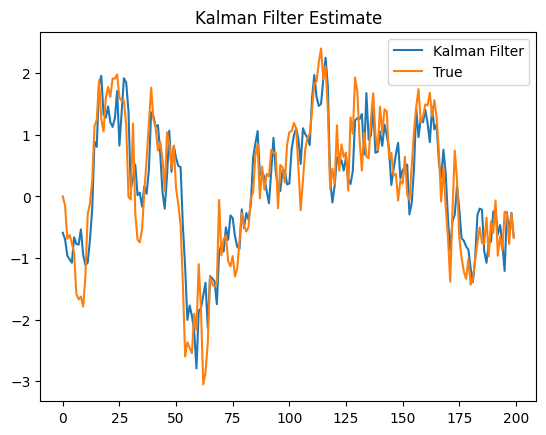

In [33]:
plt.plot(estimated_states, label="Kalman Filter")
plt.plot(x_true, label="True")
plt.legend()
plt.title("Kalman Filter Estimate")

Mean Squared Error: 0.2545826120385609
Root Mean Squared Error: 0.504561802001064


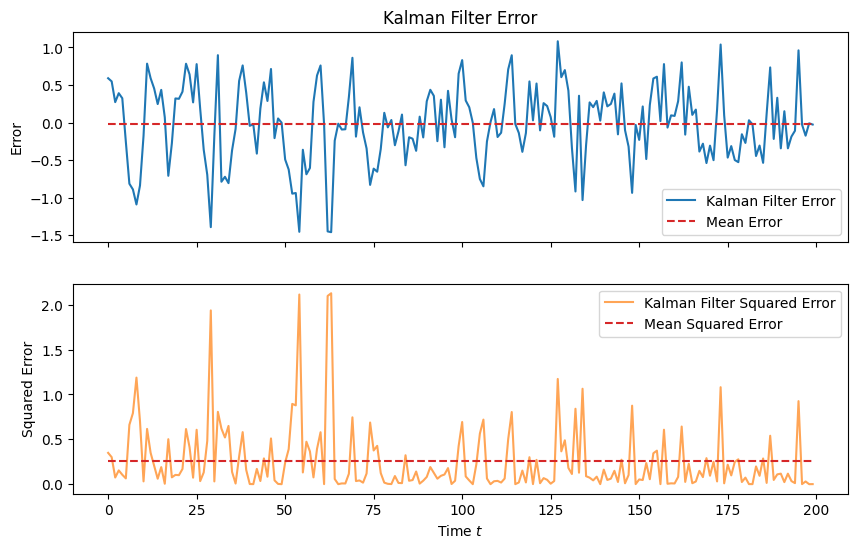

In [34]:
error =  x_true - estimated_states
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_kalman = np.square(error).mean()
RMSE_kalman = np.sqrt(MSE_kalman)
SE_sigma_kalman = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_kalman}")
print(f"Root Mean Squared Error: {RMSE_kalman}")

axes[0].plot(error, label="Kalman Filter Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("Kalman Filter Error")

axes[1].plot(error**2, label="Kalman Filter Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_kalman * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

### 3. Maximum Likelihood Estimation

Note that MLE is not a filtering approach but a smoothing approach, since it requires knowing the entire path of the observation $y_{[0:T]}$.

reading links:

https://bookdown.org/rdpeng/timeseriesbook/maximum-likelihood-with-the-kalman-filter.html

https://medium.com/data-science/the-kalman-filter-and-maximum-likelihood-9861666f6742

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

In [35]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [36]:
from scipy.optimize import minimize

# 1. Define the convex objective function
def objective(x):
    return - log_likelihood(y_obs, x, alpha_true, tau_true, phi_true, sigma_true)

# 2. Set an initial guess
x0 = np.zeros_like(x_true)

# 3. Run the optimization
# Method 'L-BFGS-B' is excellent for smooth convex problems
res_mle_filter = minimize(objective, x0, method='L-BFGS-B')

# print(f"Optimal solution: {res.x}")
# print(f"Minimum value: {res.fun}")
# print(f"Success: {res.success}")
# print(res.x.mean())

Text(0.5, 1.0, 'MLE Estimate of latent state using true parameters')

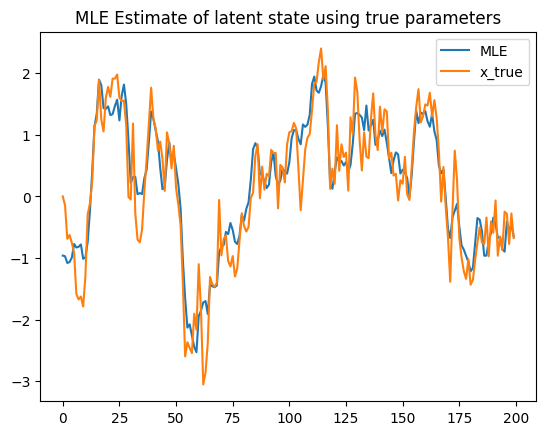

In [37]:
plt.plot(res_mle_filter.x, label = "MLE")
plt.plot(x_true, label="x_true")
plt.legend()
plt.title("MLE Estimate of latent state using true parameters")

Mean Squared Error: 0.17718539777058756
Root Mean Squared Error: 0.4209339589182459


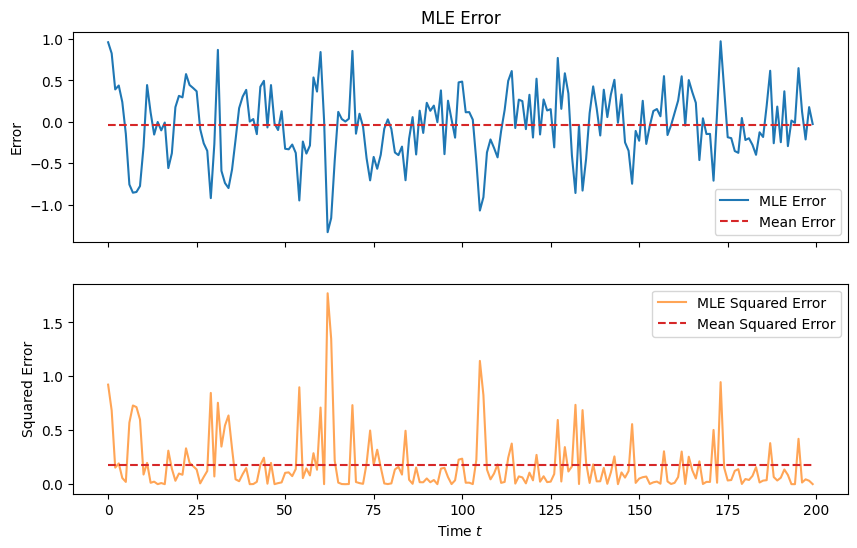

In [38]:
error =  x_true - res_mle_filter.x
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

MSE_MLE = np.square(error).mean()
RMSE_MLE = np.sqrt(MSE_MLE)
SE_sigma_MLE = np.sqrt(np.square(error).std())
print(f"Mean Squared Error: {MSE_MLE}")
print(f"Root Mean Squared Error: {RMSE_MLE}")

axes[0].plot(error, label="MLE Error", color="tab:blue")
axes[0].plot((error).mean() * np.ones_like(error), label="Mean Error", color="tab:red", linestyle='dashed')
axes[0].set_ylabel("Error")
axes[0].legend()
axes[0].set_title("MLE Error")

axes[1].plot(error**2, label="MLE Squared Error", color="tab:orange", alpha=0.7)
axes[1].plot(MSE_MLE * np.ones_like(error), label="Mean Squared Error", color="tab:red", linestyle='dashed')
axes[1].set_ylabel("Squared Error")
axes[1].set_xlabel("Time $t$")
axes[1].legend()

In [39]:
# Summary

print("\n" + "="*60)
print("                     Performance Comparison    ")
print("="*60)
print("                     MSE (\u00B1 sigma of SE)       RMSE")
print("-"*60)
print(f"Particle Filter: {MSE_particle:>10.4f} (\u00B1 {SE_sigma_particle:.4f})       {RMSE_particle:.4f} ")
print(f"Kalman Filter:   {MSE_kalman:>10.4f} (\u00B1 {SE_sigma_kalman:.4f})       {RMSE_kalman:.4f} ")
print(f"MLE:             {MSE_MLE:>10.4f} (\u00B1 {SE_sigma_MLE:.4f})       {RMSE_MLE:.4f} ")
print("="*60)


                     Performance Comparison    
                     MSE (± sigma of SE)       RMSE
------------------------------------------------------------
Particle Filter:     0.2664 (± 0.6372)       0.5161 
Kalman Filter:       0.2546 (± 0.6095)       0.5046 
MLE:                 0.1772 (± 0.5143)       0.4209 


It is reasonable that the MLE performs better since it is a smoothing approach that utilizes future informaiton, rather than a filtering method like particle filtering and kalman filter.

# Part III. Parameter Estimation Problem using only observations

### 1. MLE (Particle Filter likelihood)

We wish to maximize $l_T(\theta)$.

In [40]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [41]:
%%time
# --- Two-stage Nelder-Mead optimisation ---
# Stage 1 - cheap coarse search (fewer particles, no averaging)
# Stage 2 - refine near optimum (more particles + averaging)

np.random.seed(42)

print("Stage 1: coarse search ...")
result1 = minimize(
    neg_log_lik,
    [0.7, 1.2, np.log(0.4), np.log(0.8)],
    args=(y_obs, 500, 1),
    method="Nelder-Mead",
    options={"maxiter": 1500, "xatol": 1e-2, "fatol": 2.0, "adaptive": True}
)
print(f"  done - {result1.nit} iters")

print("Stage 2: refining ...")
result_pfmle = minimize(
    neg_log_lik,
    result1.x,
    args=(y_obs, 2000, 5),
    method="Nelder-Mead",
    options={"maxiter": 1000, "xatol": 1e-3, "fatol": 0.5, "adaptive": True}
)
print(f"  done - {result_pfmle.nit} iters\n")

phi_mle_pf, alpha_mle_pf = result_pfmle.x[0], result_pfmle.x[1]
sigma_mle_pf, tau_mle_pf = np.exp(result_pfmle.x[2]), np.exp(result_pfmle.x[3])

print("MLE Results")
print("-" * 40)
print(f"  {'param':<8} {'true':>8} {'MLE':>8}")
print(f"  {'phi':<8} {phi_true:>8.4f} {phi_mle_pf:>8.4f}")
print(f"  {'alpha':<8} {alpha_true:>8.4f} {alpha_mle_pf:>8.4f}")
print(f"  {'sigma':<8} {sigma_true:>8.4f} {sigma_mle_pf:>8.4f}")
print(f"  {'tau':<8} {tau_true:>8.4f} {tau_mle_pf:>8.4f}")
print(f"Total fun evals: {result1.nfev + result_pfmle.nfev}")

Stage 1: coarse search ...
  done - 1500 iters
Stage 2: refining ...
  done - 1000 iters

MLE Results
----------------------------------------
  param        true      MLE
  phi        0.9000   0.8897
  alpha      1.5000   1.3339
  sigma      0.5000   0.4894
  tau        1.0000   0.8021
Total fun evals: 6706
CPU times: user 4min 1s, sys: 1.95 s, total: 4min 3s
Wall time: 4min 8s


In [42]:
# Re-run PF with PF-MLE-estimated parameters and compare RMSE
np.random.seed(1)
x_pf_mle, x_particles_mle, _ = particle_filter(
    y_obs, phi_mle_pf, alpha_mle_pf, sigma_mle_pf, tau_mle_pf, N_particles=N
)

rmse_pf_true_p = np.sqrt(np.mean((x_pf_true - x_true) ** 2))
rmse_pf_mle_p  = np.sqrt(np.mean((x_pf_mle  - x_true) ** 2))

print(f"PF (true params) RMSE:  {rmse_pf_true_p:.4f}")
print(f"PF (PF-MLE params) RMSE: {rmse_pf_mle_p:.4f}")

PF (true params) RMSE:  0.5161
PF (PF-MLE params) RMSE: 0.5445


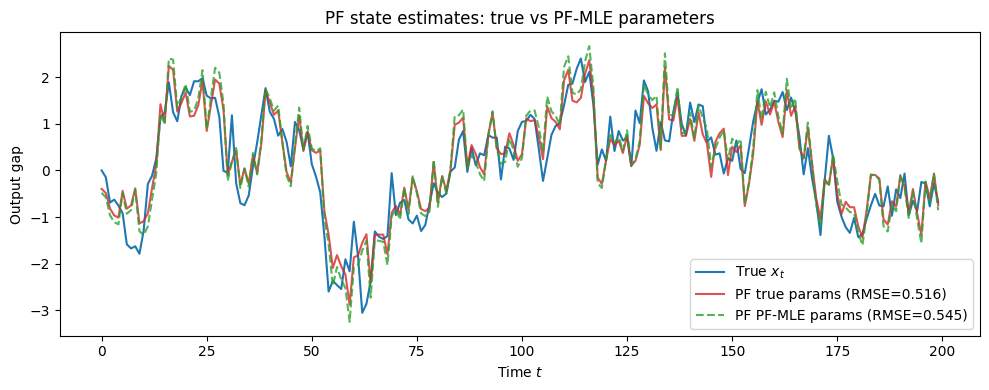

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_true, label="True $x_t$", color="tab:blue", linewidth=1.5)
ax.plot(x_pf_true, label=f"PF true params (RMSE={rmse_pf_true_p:.3f})",
        color="tab:red", alpha=0.8)
ax.plot(x_pf_mle, label=f"PF PF-MLE params (RMSE={rmse_pf_mle_p:.3f})",
        color="tab:green", alpha=0.8, linestyle="--")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Output gap")
ax.set_title("PF state estimates: true vs PF-MLE parameters")
ax.legend()
plt.tight_layout()

*Note on non-identifiability:* unlike Ricky's Kalman-MLE (which fixes $\alpha=1$ to break the $(\alpha,\sigma)$ identifiability discussed in Part I), here we estimate all four parameters freely. The PF-MLE typically recovers $\phi$ and $\sigma$ accurately, while $\alpha$ and $\tau$ are partially confounded — visible empirically in the table above. This is consistent with the model analysis in cell "Analysis of the Model, A."


### 2. MLE (Kalman Filter likelihood)

$$
\hat{\theta} = \arg\max_{\theta} p_\theta (y_{[0:T]}) = \arg\max_{\theta} \int p_\theta (x_{[0:T]}, y_{[0:T]} ) \, d x_{[0:T]}
$$

In [44]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [45]:
print("\n" + "="*80)
print(f"{'True Parameters vs. MLE Estimates (alpha fixed to 1)':^60}")
print("="*80)
print(f"{'alpha:':<7} {alpha_true:10.4f}      | {alpha_hat:10.4f}")
print(f"{'sigma:':<7} {sigma_true:10.4f}      | {sigma_hat:10.4f}")
print(f"{'tau:':<7} {tau_true:10.4f}      | {tau_hat:10.4f}")
print(f"{'phi:':<7} {phi_true:10.4f}      | {phi_hat:10.4f}")
print("="*80)



    True Parameters vs. MLE Estimates (alpha fixed to 1)    


NameError: name 'alpha_hat' is not defined

# Part IV. Results

### 6. Comparison

### 7. Statistical Testing and Sensitivity Analysis

### 8. Results and Conclusion

# Part V. Extension of Project

We extend the analysis in two directions suggested by the limitations of the previous parts: (1) full Bayesian posterior inference for $\theta$ via Particle Marginal Metropolis-Hastings, and (2) deliberate model misspecification to expose where the particle filter has a comparative advantage over the Kalman filter.

### 1. Particle Marginal Metropolis-Hastings

#### Ideal MMH

To sample from $p(x_{[0:T]}, \theta | y_{[0:T]})$,

Proposal Density:
$$
q( x'_{[0:T]}, \theta' | x_{[0:T]}, \theta) = q(\theta ' | \theta) p_{\theta '}(x'_{[0:T]} | y_{[0:T]})
$$

Acceptance probability:

$$
1 \wedge
\frac{
p_{\theta '}(y_{[0:T]})p(\theta ') q( \theta | \theta ')
}{
  p_\theta (y_{[0:T]}) p(\theta) q(\theta ' | \theta )
}
$$

For this problem, recall the closed form solution of the likelihood ratio,

$$
\Lambda(\theta' \mid \theta)
=
\frac{p_{\theta'}(y_{0:T})}{p_{\theta}(y_{0:T})}
=
\sqrt{
\frac{|\Sigma_\theta|}{|\Sigma_{\theta'}|}
}
\exp\left(
\frac{1}{2}
y^\top
\left[
\Sigma_\theta^{-1}
-
\Sigma_{\theta'}^{-1}
\right]
y
\right)
$$

where

$$
(\Sigma_\theta)_{st} = \alpha^2 \frac{\sigma^2}{1 - \phi^2}\,\phi^{|t-s|} + \tau^2 \boldsymbol{1}_{s=t}.
$$

Then the acceptance probability can be written as

$$
1 \wedge
\Lambda(\theta' \mid \theta)
\frac{
p(\theta ') q( \theta | \theta ')
}{
 p(\theta) q(\theta ' | \theta )
}
$$

#### Particle MMH

In general, the closed form solutions are not available, and we use particle filtering to approximate the density.

Sample $X'_{[0:T]}$ from the particle filter estimate $\hat{p}_{\theta '}(d x_{[0,T]} | y_{[0:T]})$. Then, calculate the acceptance probability of $(\theta', X'_{0:T})$:

$$
1 \wedge
\frac{
\hat{p}_{\theta '}(y_{[0:T]})p(\theta ') q( \theta | \theta ')
}{
\hat{p}_\theta (y_{[0:T]}) p(\theta) q(\theta ' | \theta )
}
$$

---

Building on this theoretical setup, we implement PMMH for our problem. Whereas the PF-MLE in Part III gives point estimates of $\theta = (\phi,\alpha,\sigma,\tau)$ with no uncertainty quantification, **PMMH** (Andrieu, Doucet, Holenstein 2010) provides full posterior samples. The acceptance probability above can be evaluated using the particle filter's unbiased likelihood estimator:

$$
\alpha_{\text{accept}}(\theta \to \theta') =
\min\!\left(1,\ \frac{\hat{p}_{\theta'}(y_{0:T})\,\pi(\theta')}{\hat{p}_{\theta}(y_{0:T})\,\pi(\theta)}\right).
$$

The crucial subtlety is that we do *not* recompute the likelihood at the current state — the noisy estimate from when we first accepted $\theta$ is reused. This is the *pseudo-marginal* trick: even though individual likelihood evaluations are stochastic, the resulting chain still targets the exact posterior $p(\theta \mid y_{0:T})$.

We use weakly informative priors: $\phi \sim \mathrm{Uniform}(-1, 1)$, $\alpha \sim \mathcal{N}(1, 5^2)$, $\log\sigma, \log\tau \sim \mathcal{N}(0, 2^2)$, warm-start the chain at the PF-MLE point estimates, and tune the proposal step sizes for an acceptance rate around 20--30%.

In [ ]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [ ]:
%%time
# Warm-start at PF-MLE estimates and run PMMH
np.random.seed(123)
theta0 = np.array([phi_mle_pf, alpha_mle_pf, np.log(sigma_mle_pf), np.log(tau_mle_pf)])
step_sizes = np.array([0.002, 0.05, 0.05, 0.01])
samples, acc_rate = pmmh(y_obs, n_iter=15000, N_particles=1000, step_sizes = step_sizes, theta0=theta0, seed=2)

print(f"Acceptance rate: {acc_rate:.1%}")
print(f"Total samples:   {len(samples)}")

Acceptance rate: 27.3%
Total samples:   15000
CPU times: user 7min 12s, sys: 197 ms, total: 7min 12s
Wall time: 7min 15s


In [ ]:
# discard burn-in
burn = 500
post = samples[burn:]

In [ ]:
print()
print("="*80)
print(f"{'Posterior summaries (after burn-in of ' + str(burn) + ')':^70}")
print("="*80)
print(f"  {'param':<8}  {'true':>8}  {'PF-MLE':>8}  {'post mean':>10}  {'post sd':>10}  {'95% CI':>22}")
truths = [phi_true, alpha_true, sigma_true, tau_true]
mles   = [phi_mle_pf, alpha_mle_pf, sigma_mle_pf, tau_mle_pf]
names  = ["phi", "alpha", "sigma", "tau"]
for j, name in enumerate(names):
    m   = post[:, j].mean()
    sd  = post[:, j].std()
    lo, hi = np.percentile(post[:, j], [2.5, 97.5])
    print(f"  {name:<8}  {truths[j]:>8.4f}  {mles[j]:>8.4f}  {m:>10.4f}  {sd:>10.4f}  [{lo:>7.4f}, {hi:>7.4f}]")
print("="*80)


              Posterior summaries (after burn-in of 500)              
  param         true    PF-MLE   post mean     post sd                  95% CI
  phi         0.9000    0.8897      0.9154      0.0155  [ 0.8879,  0.9596]
  alpha       1.5000    1.3339      1.4099      1.0179  [ 0.2990,  3.2241]
  sigma       0.5000    0.4894      0.6569      0.4665  [ 0.1655,  1.9576]
  tau         1.0000    0.8021      0.8882      0.0359  [ 0.8179,  0.9778]


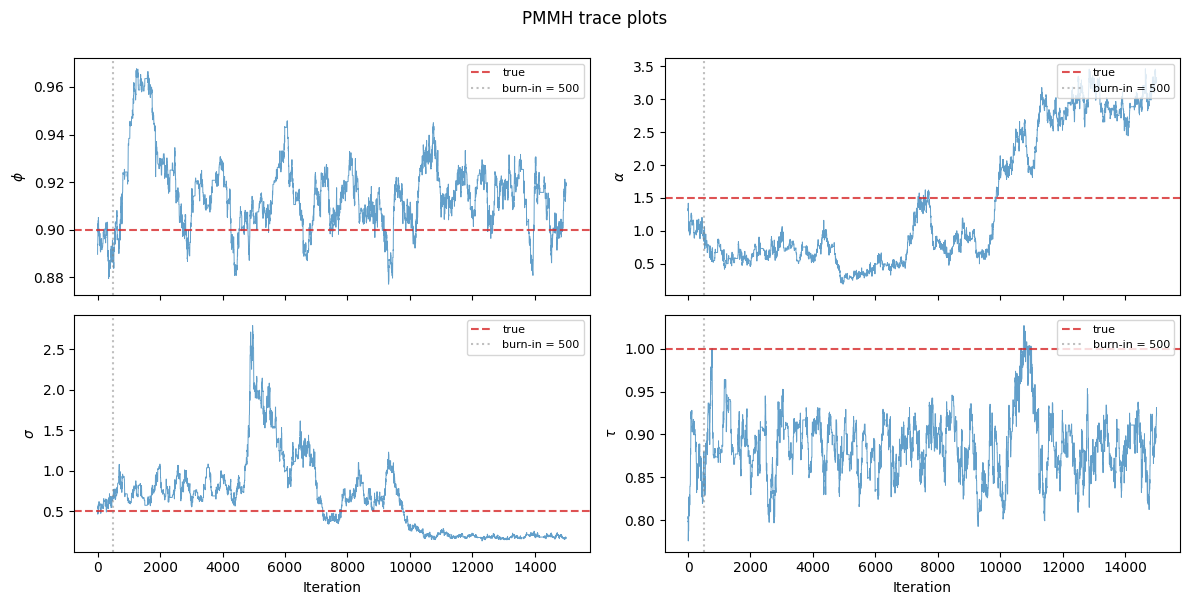

In [ ]:
# Trace plots — diagnose mixing
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
labels = [r"$\phi$", r"$\alpha$", r"$\sigma$", r"$\tau$"]
for j, ax in enumerate(axes.flat):
    ax.plot(samples[:, j], color="tab:blue", alpha=0.7, linewidth=0.7)
    ax.axhline(truths[j], color="tab:red", alpha=0.8, linestyle="--", label="true")
    ax.axvline(burn, color="gray", alpha=0.5, linestyle=":", label=f"burn-in = {burn}")
    ax.set_ylabel(labels[j])
    ax.legend(loc="upper right", fontsize=8)
axes[1, 0].set_xlabel("Iteration")
axes[1, 1].set_xlabel("Iteration")
fig.suptitle("PMMH trace plots", y=1.0)
plt.tight_layout()

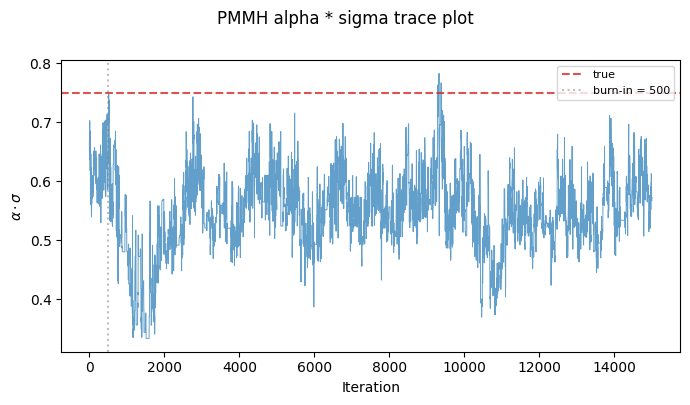

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)
axes.plot(samples[:, 1]*samples[:, 2], color="tab:blue", alpha=0.7, linewidth=0.7)
axes.axhline(alpha_true*sigma_true, color="tab:red", alpha=0.8, linestyle="--", label="true")
axes.axvline(burn, color="gray", alpha=0.5, linestyle=":", label=f"burn-in = {burn}")
axes.set_ylabel(r"$\alpha \cdot \sigma$")
axes.set_xlabel("Iteration") # Added x-label for the single plot
axes.legend(loc="upper right", fontsize=8)
fig.suptitle("PMMH alpha * sigma trace plot", y=1.0)
plt.tight_layout()

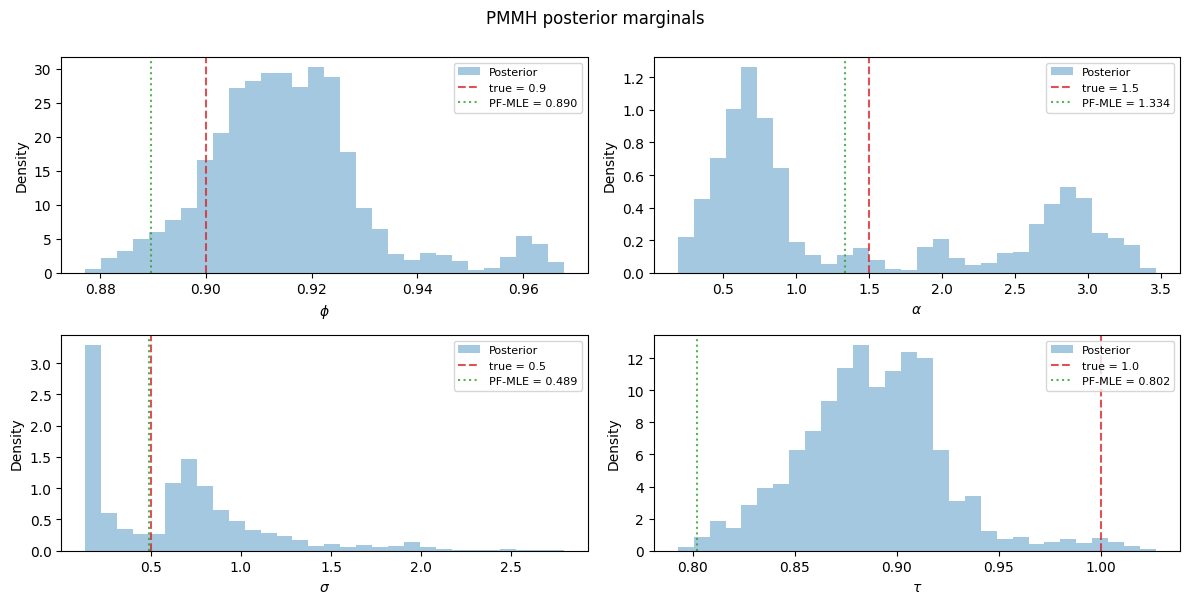

In [ ]:
# Posterior marginals
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for j, ax in enumerate(axes.flat):
    ax.hist(post[:, j], bins=30, density=True, color="tab:blue", alpha=0.4,
            label="Posterior")
    ax.axvline(truths[j], color="tab:red", alpha=0.8, linestyle="--",
               linewidth=1.5, label=f"true = {truths[j]}")
    ax.axvline(mles[j], color="tab:green", alpha=0.8, linestyle=":",
               linewidth=1.5, label=f"PF-MLE = {mles[j]:.3f}")
    ax.set_xlabel(labels[j])
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("PMMH posterior marginals", y=1.0)
plt.tight_layout()

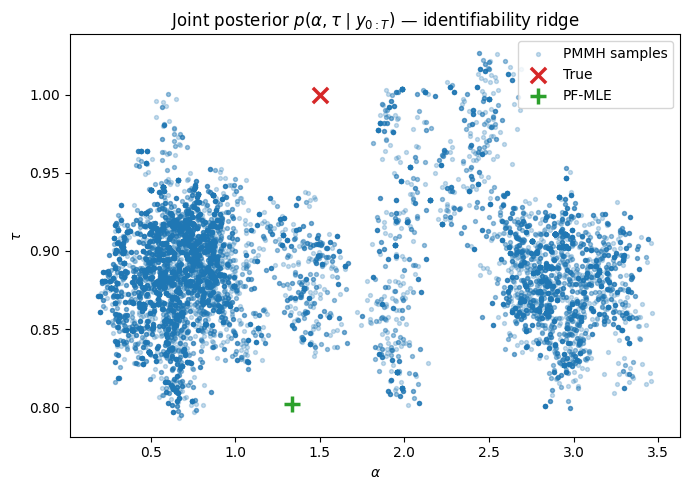

In [ ]:
# Joint posterior of (alpha, tau) — should show the identifiability ridge
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(post[:, 1], post[:, 3], color="tab:blue", alpha=0.25, s=8,
           label="PMMH samples")
ax.scatter([alpha_true], [tau_true], color="tab:red", marker="x", s=120,
           linewidth=2.5, label="True", zorder=5)
ax.scatter([alpha_mle_pf], [tau_mle_pf], color="tab:green", marker="+", s=140,
           linewidth=2.5, label="PF-MLE", zorder=5)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Joint posterior $p(\alpha, \tau \mid y_{0:T})$ — identifiability ridge")
ax.legend()
plt.tight_layout()

### 2. Model Misspecification

The linear-Gaussian setup is precisely the regime where the Kalman filter is optimal, so the PF cannot beat it. To expose where particle methods genuinely outperform the KF, we deliberately break the Gaussian assumption.

We use a *contamination model* for the measurement noise: with probability $0.9$ each $\nu_t$ is drawn from $\mathcal{N}(0, \tau^2)$ as before, but with probability $0.1$ it comes from $\mathcal{N}(0, (6\tau)^2)$ — a heavy outlier. This is a realistic form of misspecification: macroeconomic and financial series routinely exhibit occasional shocks far larger than the Gaussian model anticipates. We then run three filters:

1. **KF** assumes pure Gaussian noise — misspecified
2. **PF-Gaussian** also assumes pure Gaussian noise — misspecified
3. **PF-Student-t** uses a heavy-tailed Student-t($\nu = 4$) likelihood as a robust approximation — correctly handles the outliers

The KF and the misspecified PF should over-react to outliers; the Student-t PF should down-weight them via the t-distribution's polynomial tail decay.

In [ ]:
# Regenerate y_obs with contaminated Gaussian noise (a clear outlier scenario)
# 90% of obs from N(0, tau_true^2), 10% from N(0, (6*tau_true)^2) — heavy contamination
prob_outlier  = 0.10
tau_outlier   = 6.0 * tau_true

np.random.seed(9)
x_true_mis = np.zeros(T)
x_true_mis[0] = np.random.normal(0, sigma_true)
for t_step in range(1, T):
    x_true_mis[t_step] = phi_true * x_true_mis[t_step - 1] + np.random.normal(0, sigma_true)

# heavy-tailed observation noise: contamination mixture
rng_mis = np.random.default_rng(9)
is_outlier = rng_mis.random(T) < prob_outlier
nu = np.where(is_outlier,
              rng_mis.normal(0, tau_outlier, T),
              rng_mis.normal(0, tau_true,    T))
y_obs_mis = alpha_true * x_true_mis + nu

print(f"Contamination model: {int(prob_outlier*100)}% outliers ~ N(0, {tau_outlier}^2)")
print(f"  Number of outliers in this realisation: {is_outlier.sum()}")
print(f"  Max |noise|: {np.abs(nu).max():.2f}  (Gaussian 3-sigma would be {3*tau_true})")

Contamination model: 10% outliers ~ N(0, 6.0^2)
  Number of outliers in this realisation: 15
  Max |noise|: 13.91  (Gaussian 3-sigma would be 3.0)


In [ ]:
# Defined in particle_filter.py / state_space_model.py / regime_switching.py / analysis_utils.py

In [ ]:
# Run all three filters on the contaminated data
np.random.seed(0)
x_pf_gauss, _, _ = particle_filter(y_obs_mis, phi_true, alpha_true, sigma_true, tau_true, N_particles=10000)
# robust PF: Student-t(df=4) likelihood, scale matched to nominal tau
np.random.seed(0)
x_pf_t, _ = particle_filter_student_t(y_obs_mis, phi_true, alpha_true, sigma_true,
                                       scale=tau_true, df=4, N_particles=10000)

# KF — same Gaussian model, applied to misspecified data
kf = KalmanFilter(dim_x=1, dim_z=1)
kf.x = np.array([0.0])
kf.F = np.array([[phi_true]])
kf.H = np.array([[alpha_true]])
kf.P = np.array([[sigma_true**2 / (1 - phi_true**2)]])
kf.R = np.array([[tau_true**2]])
kf.Q = np.array([[sigma_true**2]])
x_kf_mis = []
for z in y_obs_mis:
    kf.predict(); kf.update(np.array([z]))
    x_kf_mis.append(kf.x[0])
x_kf_mis = np.array(x_kf_mis)

# RMSEs
rmse_kf_mis      = np.sqrt(np.mean((x_kf_mis    - x_true_mis) ** 2))
rmse_pf_gauss    = np.sqrt(np.mean((x_pf_gauss - x_true_mis) ** 2))
rmse_pf_t        = np.sqrt(np.mean((x_pf_t     - x_true_mis) ** 2))

print("="*65)
print(f"{'Filter RMSE under contaminated measurement noise':^65}")
print("="*65)
print(f"  Kalman Filter (Gaussian assumption):            {rmse_kf_mis:.4f}")
print(f"  PF with Gaussian likelihood (misspecified):     {rmse_pf_gauss:.4f}")
print(f"  PF with Student-t(df=4) likelihood (robust):    {rmse_pf_t:.4f}")
print("="*65)
print(f"  Improvement of robust PF over KF: "
      f"{100*(rmse_kf_mis - rmse_pf_t)/rmse_kf_mis:.1f}%")

        Filter RMSE under contaminated measurement noise         
  Kalman Filter (Gaussian assumption):            0.7692
  PF with Gaussian likelihood (misspecified):     0.7721
  PF with Student-t(df=4) likelihood (robust):    0.5719
  Improvement of robust PF over KF: 25.6%


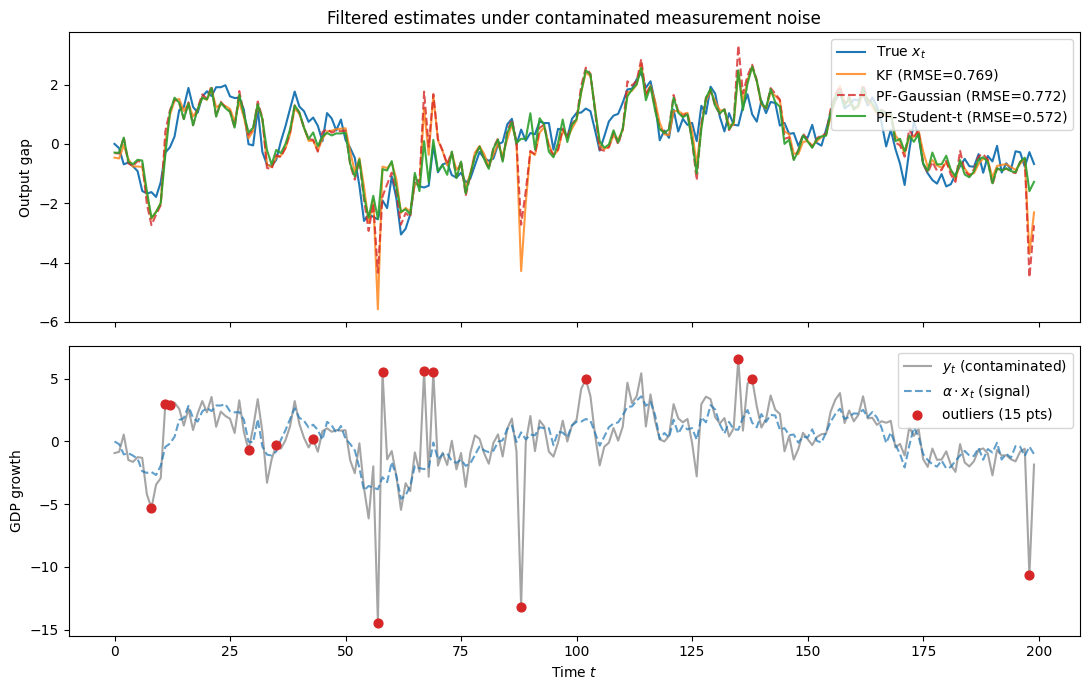

In [ ]:
# Visualise the difference
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(x_true_mis, label="True $x_t$", color="tab:blue", linewidth=1.5)
axes[0].plot(x_kf_mis,   label=f"KF (RMSE={rmse_kf_mis:.3f})",
             color="tab:orange", alpha=0.8)
axes[0].plot(x_pf_gauss, label=f"PF-Gaussian (RMSE={rmse_pf_gauss:.3f})",
             color="tab:red", alpha=0.8, linestyle="--")
axes[0].plot(x_pf_t,     label=f"PF-Student-t (RMSE={rmse_pf_t:.3f})",
             color="tab:green", alpha=0.9)
axes[0].set_ylabel("Output gap")
axes[0].set_title("Filtered estimates under contaminated measurement noise")
axes[0].legend(loc="upper right")

axes[1].plot(y_obs_mis, label="$y_t$ (contaminated)", color="tab:gray", alpha=0.7)
axes[1].plot(alpha_true * x_true_mis, label=r"$\alpha \cdot x_t$ (signal)",
             color="tab:blue", linestyle="--", alpha=0.7)
axes[1].scatter(np.where(is_outlier)[0], y_obs_mis[is_outlier],
                color="tab:red", s=40, zorder=5,
                label=f"outliers ({is_outlier.sum()} pts)")
axes[1].set_xlabel("Time $t$")
axes[1].set_ylabel("GDP growth")
axes[1].legend(loc="upper right")

plt.tight_layout()